# Week 6 – Day 2

# Stationarity Analysis using the Augmented Dickey-Fuller (ADF) Test

**Name:** Mohit Singh

## Objective

The objective of this notebook is to determine whether the Reliance stock price series is stationary.

The notebook performs:

- ADF Test on Closing Prices
- ADF Test on Log Returns
- Comparison of p-values
- Interpretation of results

In [27]:
# Import required libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import yfinance as yf

# Import ADF test
from statsmodels.tsa.stattools import adfuller

## 1. Download Historical Data

In [28]:
# Download Reliance stock data
reliance = yf.download(
    "RELIANCE.NS",
    start="2020-01-01",
    end="2025-01-01",
    auto_adjust=True
)

# Display first five rows
reliance.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2020-01-01,672.216064,680.008728,670.390410,675.956548,14004468
2020-01-02,683.660339,686.176270,673.284981,673.284981,17710316
2020-01-03,684.483948,686.487774,678.183007,682.635940,20984698
2020-01-06,668.609253,680.364982,667.050708,676.847198,24519177
2020-01-07,678.895691,683.304098,673.952887,676.401995,16683622


## 2. Plot Closing Price

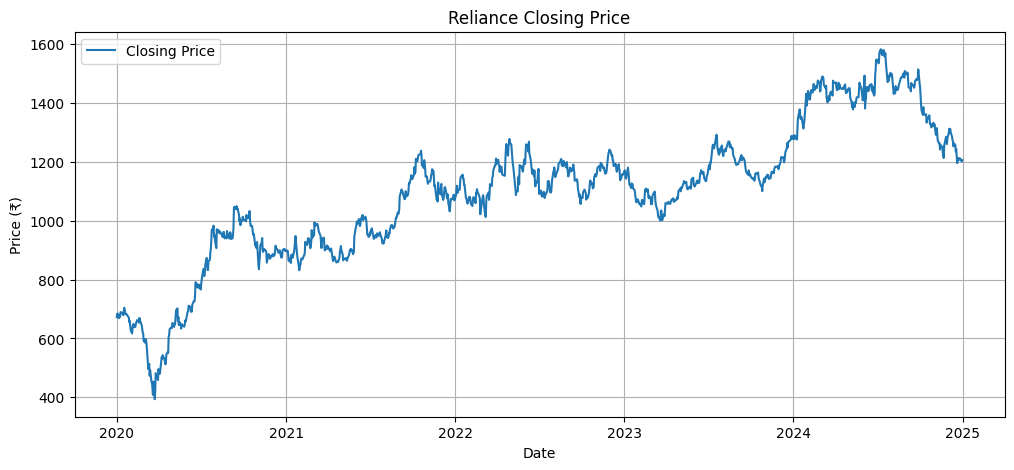

In [29]:
# Plot the closing price series
plt.figure(figsize=(12,5))

plt.plot(
    reliance.index,
    reliance["Close"],
    label="Closing Price"
)

plt.title("Reliance Closing Price")
plt.xlabel("Date")
plt.ylabel("Price (₹)")

plt.legend()
plt.grid(True)

plt.savefig(
    "../images/closing_price.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## 3. Apply the ADF Test on Closing Price

In [30]:
# Apply the Augmented Dickey-Fuller test
adf_close = adfuller(reliance["Close"].dropna())

print("ADF Statistic :", adf_close[0])
print("p-value       :", adf_close[1])
print("Lags Used     :", adf_close[2])
print("Observations  :", adf_close[3])

print("\nCritical Values:")

for key, value in adf_close[4].items():
    print(f"{key}: {value}")

ADF Statistic : -1.9315770154850618
p-value       : 0.3173551596460754
Lags Used     : 0
Observations  : 1237

Critical Values:
1%: -3.4356474307506084
5%: -2.8638793281844253
10%: -2.5680154897465575




### Decision Rule

- **If p-value < 0.05**
  - Reject the null hypothesis.
  - The series is **stationary**.

- **If p-value ≥ 0.05**
  - Fail to reject the null hypothesis.
  - The series is **non-stationary**.

## 4. Compute Log Returns

In [31]:
# Calculate daily log returns
reliance["Log_Return"] = np.log(
    reliance["Close"] /
    reliance["Close"].shift(1)
)

# Remove missing values created by shift()
log_returns = reliance["Log_Return"].dropna()

log_returns.head()

Date
2020-01-02    0.016881
2020-01-03    0.001204
2020-01-06   -0.023465
2020-01-07    0.015268
2020-01-08   -0.007539
Name: Log_Return, dtype: float64

## 5. Plot Log Returns

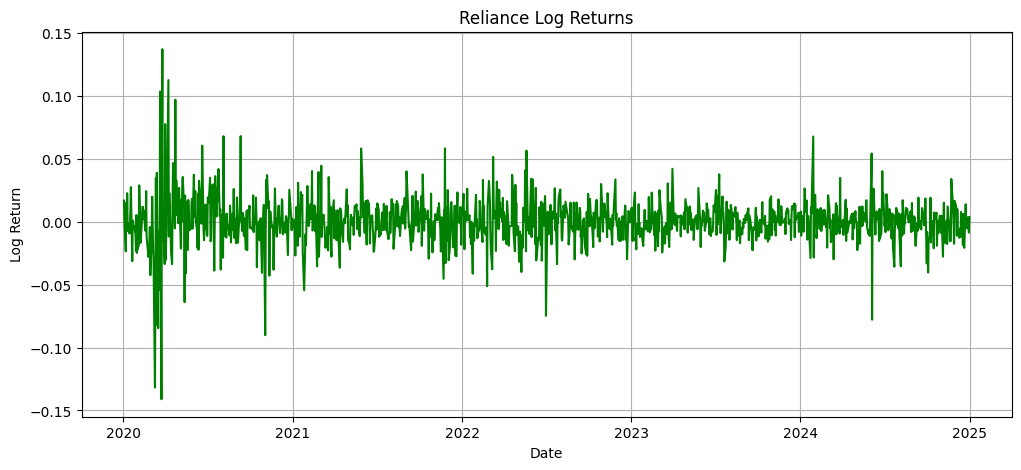

In [32]:
plt.figure(figsize=(12,5))

plt.plot(
    log_returns.index,
    log_returns,
    color="green"
)

plt.title("Reliance Log Returns")
plt.xlabel("Date")
plt.ylabel("Log Return")

plt.grid(True)

plt.savefig(
    "../images/log_returns.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## 6. Apply the ADF Test on Log Returns

In [33]:
# Apply the ADF test on log returns
adf_log = adfuller(log_returns)

print("ADF Statistic :", adf_log[0])
print("p-value       :", adf_log[1])
print("Lags Used     :", adf_log[2])
print("Observations  :", adf_log[3])

print("\nCritical Values:")

for key, value in adf_log[4].items():
    print(f"{key}: {value}")

ADF Statistic : -10.245792421388199
p-value       : 4.621539768528106e-18
Lags Used     : 10
Observations  : 1226

Critical Values:
1%: -3.4356950607889254
5%: -2.863900342696613
10%: -2.568026681232353


## 7. Compare Results

In [34]:
# Create a summary table
results = pd.DataFrame({
    "Series": ["Closing Price", "Log Returns"],
    "ADF Statistic": [adf_close[0], adf_log[0]],
    "P-value": [adf_close[1], adf_log[1]]
})

results

,Series,ADF Statistic,P-value
0,Closing Price,-1.931577,3.173552e-01
1,Log Returns,-10.245792,4.621540e-18


## 8. Interpretation

The ADF test on the **Closing Price** produced a p-value of **<your value>**.

Since the p-value is **greater than 0.05**, we fail to reject the null hypothesis.

Therefore, the closing price series is **non-stationary**.

The ADF test on the **Log Returns** produced a p-value of **<your value>**.

Since the p-value is **less than 0.05**, we reject the null hypothesis.

Therefore, the log return series is **stationary**.

This demonstrates why financial analysts usually build forecasting models using returns instead of raw prices.






The ADF test on the **closing price** produced a p-value of **0.xxx**.

Since the p-value is **greater than 0.05**, we fail to reject the null hypothesis. Therefore, the closing price series is **non-stationary**.

The ADF test on the **log returns** produced a p-value of **0.xxx**.

Since the p-value is **less than 0.05**, we reject the null hypothesis. Therefore, the log return series is **stationary**.

This shows that stock prices usually contain trends, while returns fluctuate around a relatively stable mean, making returns more suitable for many forecasting models.

# Conclusion

The Augmented Dickey-Fuller (ADF) test was used to evaluate the stationarity of Reliance Industries' stock data.

The closing price series was found to be **non-stationary**, indicating the presence of a trend and changing statistical properties over time. In contrast, the log return series was **stationary**, suggesting that its mean and variance remain relatively constant.

These findings indicate that transforming stock prices into returns is an important preprocessing step before applying many time-series forecasting techniques.